In [2]:
!pip install textblob

In [3]:
import pandas as pd
import numpy as np
import re
import joblib
import warnings
warnings.filterwarnings("ignore")

from textblob import TextBlob
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import classification_report, f1_score
from sklearn.preprocessing import LabelEncoder
from scipy.sparse import hstack, csr_matrix

# ---- Load saved data ----
print("Loading data...", end=" ")
X_train = joblib.load("models_v3/X_train.pkl")
X_val   = joblib.load("models_v3/X_val.pkl")
X_test  = joblib.load("models_v3/X_test.pkl")
y_train = joblib.load("models_v3/y_train.pkl")
y_val   = joblib.load("models_v3/y_val.pkl")
y_test  = joblib.load("models_v3/y_test.pkl")
label_classes = joblib.load("models_v3/label_classes.pkl")
print("Done ✅")

# ---- Load existing model & vectorizer ----
print("Loading models...", end=" ")
lr_v3    = joblib.load("models_v3/logistic_regression_model.pkl")
tfidf_v3 = joblib.load("models_v3/tfidf_vectorizer.pkl")
le_v3    = joblib.load("models_v3/label_encoder.pkl")
print("Done ✅")

print("\nData shapes:")
print(f"  X_train: {X_train.shape} | y_train: {y_train.shape}")
print(f"  X_val:   {X_val.shape}   | y_val:   {y_val.shape}")
print(f"  X_test:  {X_test.shape}  | y_test:  {y_test.shape}")
print(f"\nLabel classes: {label_classes}")

Loading data... Done ✅
Loading models... Done ✅

Data shapes:
  X_train: (15324,) | y_train: (15324,)
  X_val:   (3274,)   | y_val:   (3274,)
  X_test:  (3282,)  | y_test:  (3282,)

Label classes: ['anxiety' 'depression' 'loneliness' 'normal' 'suicidal']


In [4]:
# ---- Preprocess function ----
def preprocess(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+", "", text)
    text = re.sub(r"@\w+", "", text)
    text = re.sub(r"[^a-z\s]", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

# ---- Verify baseline model still works ----
X_val_tfidf = tfidf_v3.transform(X_val)
y_val_pred  = lr_v3.predict(X_val_tfidf)

print("--- Baseline V3 Validation Performance ---")
print(classification_report(y_val, y_val_pred, target_names=label_classes))

baseline_f1 = f1_score(y_val, y_val_pred, average="macro")
print(f"Baseline Macro F1: {baseline_f1:.4f}")

--- Baseline V3 Validation Performance ---
              precision    recall  f1-score   support

     anxiety       0.85      0.85      0.85       662
  depression       0.55      0.52      0.54       658
  loneliness       0.74      0.77      0.76       638
      normal       0.93      0.97      0.95       667
    suicidal       0.64      0.62      0.63       649

    accuracy                           0.75      3274
   macro avg       0.74      0.75      0.75      3274
weighted avg       0.74      0.75      0.75      3274

Baseline Macro F1: 0.7452


In [5]:
# ---- Layer 1: Confidence Thresholding ----

def predict_with_threshold(text, threshold=0.40):
    cleaned    = preprocess(text)
    vectorized = tfidf_v3.transform([cleaned])
    proba      = lr_v3.predict_proba(vectorized)[0]
    pred_enc   = proba.argmax()
    confidence = proba.max()
    pred_label = label_classes[pred_enc]
    
    # If model isn't confident enough → return uncertain
    if confidence < threshold:
        return "uncertain", confidence, proba
    
    return pred_label, confidence, proba

# ---- Test on tricky normal cases ----
tricky_normal = [
    "I was so tired after work today but the pizza I ordered totally made up for it",
    "Ugh Monday again, at least coffee exists",
    "Traffic was terrible this morning, took me an hour to get to work",
    "Just finished a great workout at the gym, feeling energized!",
    "Made pasta for dinner tonight, turned out really well"
]

print("--- Threshold Test on Tricky Normal Cases ---\n")
for text in tricky_normal:
    label, conf, proba = predict_with_threshold(text, threshold=0.40)
    scores = {label_classes[i]: round(float(proba[i])*100, 2) for i in range(len(label_classes))}
    scores = dict(sorted(scores.items(), key=lambda x: x[1], reverse=True))
    print(f"Text       : {text[:65]}...")
    print(f"Prediction : {label.upper()} ({round(conf*100, 2)}%)")
    top3 = list(scores.items())[:3]
    print(f"Top 3      : {top3}")
    print("-" * 55)

--- Threshold Test on Tricky Normal Cases ---

Text       : I was so tired after work today but the pizza I ordered totally m...
Prediction : DEPRESSION (47.25%)
Top 3      : [('depression', 47.25), ('normal', 20.84), ('suicidal', 17.86)]
-------------------------------------------------------
Text       : Ugh Monday again, at least coffee exists...
Prediction : DEPRESSION (54.83%)
Top 3      : [('depression', 54.83), ('suicidal', 20.65), ('normal', 13.82)]
-------------------------------------------------------
Text       : Traffic was terrible this morning, took me an hour to get to work...
Prediction : SUICIDAL (41.13%)
Top 3      : [('suicidal', 41.13), ('depression', 29.64), ('anxiety', 15.13)]
-------------------------------------------------------
Text       : Just finished a great workout at the gym, feeling energized!...
Prediction : NORMAL (93.89%)
Top 3      : [('normal', 93.89), ('depression', 2.27), ('loneliness', 1.84)]
----------------------------------------------------

In [6]:
# ---- Layer 2: Sentiment-Aware Post Processing ----

def get_sentiment(text):
    blob = TextBlob(text)
    return blob.sentiment.polarity, blob.sentiment.subjectivity

def predict_with_sentiment(text, threshold=0.40):
    cleaned    = preprocess(text)
    vectorized = tfidf_v3.transform([cleaned])
    proba      = lr_v3.predict_proba(vectorized)[0]
    pred_enc   = proba.argmax()
    confidence = proba.max()
    pred_label = label_classes[pred_enc]
    
    # Get sentiment of ORIGINAL text (not cleaned)
    polarity, subjectivity = get_sentiment(text)
    
    scores = {label_classes[i]: round(float(proba[i])*100, 2) 
              for i in range(len(label_classes))}
    
    # ---- Sentiment Override Rules ----
    
    # Rule 1: Clearly positive → override to normal
    # Polarity > 0.3 and predicted as depression/suicidal/loneliness
    if polarity > 0.3 and pred_label in ["depression", "suicidal", "loneliness"]:
        pred_label = "normal"
        confidence = scores.get("normal", 0) / 100
    
    # Rule 2: Low confidence → uncertain
    elif confidence < threshold:
        pred_label = "uncertain"
    
    # Rule 3: Mildly positive + depression predicted → uncertain
    elif polarity > 0.1 and pred_label == "depression" and confidence < 0.55:
        pred_label = "uncertain"

    return pred_label, round(confidence * 100, 2), polarity, scores

# ---- Test on ALL non-obvious cases ----
test_cases = [
    # Normal cases
    ("I was so tired after work today but the pizza I ordered totally made up for it", "NORMAL"),
    ("Ugh Monday again, at least coffee exists",                                       "NORMAL"),
    ("Traffic was terrible this morning, took me an hour to get to work",              "NORMAL"),
    ("My team lost the match today but it was still a fun game",                       "NORMAL"),
    # Anxiety cases
    ("I keep replaying the conversation I had with my boss over and over",             "ANXIETY"),
    ("I checked the door three times before leaving, still not sure I locked it",      "ANXIETY"),
    ("I cancelled plans again because I just couldn't face being around people",       "ANXIETY"),
    ("Every time my phone rings from an unknown number my stomach drops",              "ANXIETY"),
    # Depression cases
    ("I showered today. That's the most I've done all week",                           "DEPRESSION"),
    ("Ate something for the first time since yesterday, didn't really taste anything", "DEPRESSION"),
    ("I keep saying I'll start tomorrow but tomorrow never comes",                     "DEPRESSION"),
    ("I used to love painting, haven't touched my brushes in months",                 "DEPRESSION"),
    # Loneliness cases
    ("I laugh the loudest in the group but drive home in complete silence",            "LONELINESS"),
    ("My notifications are full but none of them are from someone checking on me",    "LONELINESS"),
    ("I'm surrounded by people at this party and I've never felt more invisible",     "LONELINESS"),
    ("I reply instantly but nobody notices when I go quiet for days",                 "LONELINESS"),
    # Suicidal cases
    ("I've started giving away things I care about, don't really need them anymore",  "SUICIDAL"),
    ("I'm just so tired of waking up every single day to the same pain",              "SUICIDAL"),
    ("I've been researching ways to just disappear",                                  "SUICIDAL"),
    ("Made sure all my affairs are in order, feels like a weight off my shoulders",   "SUICIDAL"),
]

print("--- Layer 2 Results ---\n")
correct = 0
uncertain_count = 0

for text, expected in test_cases:
    pred, conf, polarity, scores = predict_with_sentiment(text)
    
    is_correct  = pred.upper() == expected
    is_uncertain = pred == "uncertain"
    
    if is_correct:   correct += 1
    if is_uncertain: uncertain_count += 1
    
    status = "✅" if is_correct else ("🟡" if is_uncertain else "❌")
    print(f"{status} Expected: {expected:<12} Got: {pred.upper():<12} "
          f"Conf: {conf}%  Polarity: {round(polarity,2)}")

print(f"\nCorrect        : {correct}/{len(test_cases)}")
print(f"Uncertain      : {uncertain_count}/{len(test_cases)}")
print(f"Wrong          : {len(test_cases) - correct - uncertain_count}/{len(test_cases)}")

--- Layer 2 Results ---

❌ Expected: NORMAL       Got: DEPRESSION   Conf: 47.25%  Polarity: -0.2
❌ Expected: NORMAL       Got: DEPRESSION   Conf: 54.83%  Polarity: -0.3
❌ Expected: NORMAL       Got: SUICIDAL     Conf: 41.13%  Polarity: -1.0
✅ Expected: NORMAL       Got: NORMAL       Conf: 41.28%  Polarity: -0.05
✅ Expected: ANXIETY      Got: ANXIETY      Conf: 49.41%  Polarity: 0.0
🟡 Expected: ANXIETY      Got: UNCERTAIN    Conf: 39.04%  Polarity: -0.25
❌ Expected: ANXIETY      Got: DEPRESSION   Conf: 43.82%  Polarity: 0.0
✅ Expected: ANXIETY      Got: ANXIETY      Conf: 47.89%  Polarity: -0.1
❌ Expected: DEPRESSION   Got: NORMAL       Conf: 11.71%  Polarity: 0.5
🟡 Expected: DEPRESSION   Got: UNCERTAIN    Conf: 26.12%  Polarity: 0.23
❌ Expected: DEPRESSION   Got: SUICIDAL     Conf: 48.65%  Polarity: 0.0
❌ Expected: DEPRESSION   Got: NORMAL       Conf: 22.03%  Polarity: 0.5
❌ Expected: LONELINESS   Got: NORMAL       Conf: 42.15%  Polarity: 0.2
❌ Expected: LONELINESS   Got: NORMAL       

In [7]:
import nltk
nltk.download('wordnet')
nltk.download('averaged_perceptron_tagger')
nltk.download('stopwords')

from nltk.stem import WordNetLemmatizer
from nltk.corpus import stopwords

lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

# Keep these even though they're stopwords — carry emotional signal
KEEP_WORDS = {
    "no", "not", "never", "nothing", "nobody", "nowhere",
    "cannot", "cant", "wont", "dont", "didnt", "wasnt",
    "me", "my", "myself", "i", "alone", "empty"
}

stop_words = stop_words - KEEP_WORDS

def preprocess_v2(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+", "", text)        # remove URLs
    text = re.sub(r"@\w+", "", text)                  # remove mentions

    # Expand contractions
    contractions = {
        "can't": "cannot", "won't": "will not", "don't": "do not",
        "didn't": "did not", "wasn't": "was not", "i'm": "i am",
        "i've": "i have", "i'll": "i will", "i'd": "i would",
        "it's": "it is", "that's": "that is", "there's": "there is",
        "they're": "they are", "we're": "we are", "you're": "you are",
        "couldn't": "could not", "wouldn't": "would not",
        "shouldn't": "should not", "isn't": "is not", "aren't": "are not"
    }
    for contraction, expansion in contractions.items():
        text = text.replace(contraction, expansion)

    text = re.sub(r"[^a-z\s]", "", text)              # remove punctuation
    
    # Tokenize, remove stopwords, lemmatize
    tokens = text.split()
    tokens = [lemmatizer.lemmatize(w) for w in tokens if w not in stop_words]
    
    return " ".join(tokens).strip()

# Test it
samples = [
    "I've been feeling really down and hopeless for weeks now",
    "I can't stop worrying about everything, my heart is always racing",
    "I feel so happy today, just had a great time with friends!"
]

print("--- Preprocessing Comparison ---\n")
for s in samples:
    print(f"Original : {s}")
    print(f"V2       : {preprocess_v2(s)}")
    print()

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\jaisw\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     C:\Users\jaisw\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\jaisw\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


--- Preprocessing Comparison ---

Original : I've been feeling really down and hopeless for weeks now
V2       : i feeling really hopeless week

Original : I can't stop worrying about everything, my heart is always racing
V2       : i cannot stop worrying everything my heart always racing

Original : I feel so happy today, just had a great time with friends!
V2       : i feel happy today great time friend



In [8]:
from textblob import TextBlob

# Mental health lexicons
SUICIDAL_WORDS  = [
    "die", "death", "kill", "suicide", "suicidal", "end my life",
    "no reason to live", "better off without me", "want to disappear",
    "cant go on", "giving up", "goodbye", "farewell", "last day"
]
DEPRESSION_WORDS = [
    "hopeless", "worthless", "empty", "numb", "pointless", "meaningless",
    "exhausted", "drained", "hollow", "defeated", "burden", "broken",
    "helpless", "miserable", "despair", "trapped", "stuck"
]
ANXIETY_WORDS = [
    "panic", "anxious", "anxiety", "worry", "scared", "fear", "nervous",
    "overwhelmed", "racing", "overthinking", "restless", "tense",
    "dreading", "terrified", "uneasy", "apprehensive"
]
LONELINESS_WORDS = [
    "alone", "lonely", "isolated", "invisible", "disconnected", "abandoned",
    "unwanted", "forgotten", "nobody", "no one", "unloved", "rejected"
]
POSITIVE_WORDS = [
    "happy", "excited", "grateful", "blessed", "wonderful", "fantastic",
    "amazing", "great", "joy", "love", "cheerful", "delighted", "peaceful",
    "content", "proud", "thrilled", "relaxed", "energized"
]

def extract_features(text):
    text_lower = text.lower()
    words      = text_lower.split()
    word_count = len(words) if len(words) > 0 else 1
    blob       = TextBlob(text)
    
    # Lexicon scores
    suicidal_score  = sum(1 for w in SUICIDAL_WORDS  if w in text_lower) / word_count
    depression_score= sum(1 for w in DEPRESSION_WORDS if w in text_lower) / word_count
    anxiety_score   = sum(1 for w in ANXIETY_WORDS   if w in text_lower) / word_count
    loneliness_score= sum(1 for w in LONELINESS_WORDS if w in text_lower) / word_count
    positive_score  = sum(1 for w in POSITIVE_WORDS  if w in text_lower) / word_count

    # Structural features
    first_person    = sum(1 for w in words if w in 
                         ["i", "me", "my", "myself", "mine"]) / word_count
    neg_words       = sum(1 for w in words if w in 
                         ["not", "no", "never", "nobody", "nothing", 
                          "nowhere", "cannot", "nor"]) / word_count
    exclamation     = text.count("!") / word_count
    question        = text.count("?") / word_count
    caps_ratio      = sum(1 for c in text if c.isupper()) / (len(text) + 1)
    avg_word_len    = np.mean([len(w) for w in words]) if words else 0
    
    # Sentiment
    polarity        = blob.sentiment.polarity
    subjectivity    = blob.sentiment.subjectivity
    
    return np.array([
        suicidal_score, depression_score, anxiety_score,
        loneliness_score, positive_score, first_person,
        neg_words, exclamation, question, caps_ratio,
        avg_word_len, polarity, subjectivity,
        word_count / 500  # normalized
    ])

# Test on samples
print("--- Feature Extraction Test ---\n")
feature_names = [
    "suicidal_score", "depression_score", "anxiety_score",
    "loneliness_score", "positive_score", "first_person_ratio",
    "negative_word_ratio", "exclamation_ratio", "question_ratio",
    "caps_ratio", "avg_word_length", "polarity", "subjectivity",
    "normalized_length"
]

test_texts = [
    "I don't see any point in living anymore, everything is falling apart",
    "I feel so happy today, just had a great time with friends!",
    "I keep overthinking every little thing and I can't make it stop"
]

for text in test_texts:
    features = extract_features(text)
    print(f"Text: {text[:60]}...")
    for name, val in zip(feature_names, features):
        if val > 0:
            print(f"  {name:<25} {val:.4f}")
    print()

--- Feature Extraction Test ---

Text: I don't see any point in living anymore, everything is falli...
  first_person_ratio        0.0833
  caps_ratio                0.0145
  avg_word_length           4.7500
  normalized_length         0.0240

Text: I feel so happy today, just had a great time with friends!...
  positive_score            0.1667
  first_person_ratio        0.0833
  exclamation_ratio         0.0833
  caps_ratio                0.0169
  avg_word_length           3.9167
  polarity                  0.9000
  subjectivity              0.8750
  normalized_length         0.0240

Text: I keep overthinking every little thing and I can't make it s...
  anxiety_score             0.0833
  first_person_ratio        0.1667
  caps_ratio                0.0312
  avg_word_length           4.3333
  subjectivity              0.5000
  normalized_length         0.0240



In [9]:
# Expanded mental health lexicons
SUICIDAL_WORDS = [
    "die", "death", "dead", "kill", "suicide", "suicidal",
    "end my life", "end it all", "no reason to live", "not worth living",
    "better off without me", "want to disappear", "cant go on",
    "giving up", "goodbye", "farewell", "last day", "no point living",
    "point in living", "dont want to exist", "want to die",
    "tired of living", "tired of fighting", "falling apart",
    "cant take it anymore", "done with life", "affairs in order",
    "giving away", "no way out", "disappear", "waking up anymore"
]

DEPRESSION_WORDS = [
    "hopeless", "worthless", "empty", "numb", "pointless", "meaningless",
    "exhausted", "drained", "hollow", "defeated", "burden", "broken",
    "helpless", "miserable", "despair", "trapped", "stuck", "sad",
    "unhappy", "down", "depressed", "depression", "crying", "tears",
    "unmotivated", "no motivation", "cant get up", "bed all day",
    "no energy", "no appetite", "no taste", "no interest", "no joy",
    "used to love", "dont enjoy", "stopped caring", "gave up",
    "not sleeping", "oversleeping", "no future", "no hope",
    "falling apart", "breaking down", "cant cope", "no point"
]

ANXIETY_WORDS = [
    "panic", "panicking", "anxious", "anxiety", "worry", "worried",
    "scared", "fear", "nervous", "overwhelmed", "racing", "overthinking",
    "restless", "tense", "dreading", "terrified", "uneasy", "apprehensive",
    "heart racing", "cant breathe", "shaking", "trembling", "sweating",
    "replaying", "what if", "stomach drops", "checked", "triple checked",
    "cant relax", "on edge", "spiral", "spiraling", "doom", "dread",
    "catastrophe", "worst case", "cant stop thinking", "intrusive"
]

LONELINESS_WORDS = [
    "alone", "lonely", "loneliness", "isolated", "invisible", "disconnected",
    "abandoned", "unwanted", "forgotten", "nobody", "no one", "unloved",
    "rejected", "no friends", "no one cares", "nobody checks", "misunderstood",
    "no connection", "feel empty", "silence", "quiet", "excluded",
    "left out", "no one understands", "nobody understands", "all alone",
    "by myself", "no one to talk", "no one notices", "unheard", "unseen"
]

POSITIVE_WORDS = [
    "happy", "happiness", "excited", "grateful", "blessed", "wonderful",
    "fantastic", "amazing", "great", "joy", "joyful", "love", "loved",
    "cheerful", "delighted", "peaceful", "content", "proud", "thrilled",
    "relaxed", "energized", "refreshed", "good", "excellent", "perfect",
    "enjoy", "enjoyed", "fun", "laugh", "laughing", "smile", "smiling",
    "celebrate", "celebration", "positive", "optimistic", "hopeful",
    "motivated", "inspired", "accomplished", "succeed", "winning"
]

# Update extract_features with new lexicons
def extract_features(text):
    text_lower = text.lower()
    words      = text_lower.split()
    word_count = len(words) if len(words) > 0 else 1
    blob       = TextBlob(text)

    suicidal_score   = sum(1 for w in SUICIDAL_WORDS   if w in text_lower) / word_count
    depression_score = sum(1 for w in DEPRESSION_WORDS if w in text_lower) / word_count
    anxiety_score    = sum(1 for w in ANXIETY_WORDS    if w in text_lower) / word_count
    loneliness_score = sum(1 for w in LONELINESS_WORDS if w in text_lower) / word_count
    positive_score   = sum(1 for w in POSITIVE_WORDS   if w in text_lower) / word_count

    first_person  = sum(1 for w in words if w in
                       ["i", "me", "my", "myself", "mine"]) / word_count
    neg_words     = sum(1 for w in words if w in
                       ["not", "no", "never", "nobody", "nothing",
                        "nowhere", "cannot", "nor"]) / word_count
    exclamation   = text.count("!") / word_count
    question      = text.count("?") / word_count
    caps_ratio    = sum(1 for c in text if c.isupper()) / (len(text) + 1)
    avg_word_len  = np.mean([len(w) for w in words]) if words else 0
    polarity      = blob.sentiment.polarity
    subjectivity  = blob.sentiment.subjectivity

    return np.array([
        suicidal_score, depression_score, anxiety_score,
        loneliness_score, positive_score, first_person,
        neg_words, exclamation, question, caps_ratio,
        avg_word_len, polarity, subjectivity,
        word_count / 500
    ])

# Retest
feature_names = [
    "suicidal_score", "depression_score", "anxiety_score",
    "loneliness_score", "positive_score", "first_person_ratio",
    "negative_word_ratio", "exclamation_ratio", "question_ratio",
    "caps_ratio", "avg_word_length", "polarity", "subjectivity",
    "normalized_length"
]

test_texts = [
    ("I don't see any point in living anymore, everything is falling apart", "SUICIDAL"),
    ("I feel so happy today, just had a great time with friends!",           "NORMAL"),
    ("I keep overthinking every little thing and I can't make it stop",      "ANXIETY"),
    ("I showered today. That's the most I've done all week",                 "DEPRESSION"),
    ("Nobody understands me, I feel completely alone in this world",         "LONELINESS"),
]

print("--- Expanded Lexicon Feature Test ---\n")
for text, expected in test_texts:
    features = extract_features(text)
    print(f"Expected : {expected}")
    print(f"Text     : {text[:65]}...")
    for name, val in zip(feature_names, features):
        if val > 0:
            print(f"  {name:<25} {val:.4f}")
    print()

--- Expanded Lexicon Feature Test ---

Expected : SUICIDAL
Text     : I don't see any point in living anymore, everything is falling ap...
  suicidal_score            0.1667
  depression_score          0.0833
  first_person_ratio        0.0833
  caps_ratio                0.0145
  avg_word_length           4.7500
  normalized_length         0.0240

Expected : NORMAL
Text     : I feel so happy today, just had a great time with friends!...
  positive_score            0.1667
  first_person_ratio        0.0833
  exclamation_ratio         0.0833
  caps_ratio                0.0169
  avg_word_length           3.9167
  polarity                  0.9000
  subjectivity              0.8750
  normalized_length         0.0240

Expected : ANXIETY
Text     : I keep overthinking every little thing and I can't make it stop...
  anxiety_score             0.0833
  first_person_ratio        0.1667
  caps_ratio                0.0312
  avg_word_length           4.3333
  subjectivity              0.5000
  norm

In [10]:
from scipy.sparse import hstack, csr_matrix

print("Building improved TF-IDF with lemmatized text...")

# Step 1 — Apply new preprocessor to all splits
X_train_clean = np.array([preprocess_v2(t) for t in X_train])
X_val_clean   = np.array([preprocess_v2(t) for t in X_val])
X_test_clean  = np.array([preprocess_v2(t) for t in X_test])
print("✅ Preprocessing done")

# Step 2 — New TF-IDF on lemmatized text
tfidf_v4 = TfidfVectorizer(
    max_features=75000,
    ngram_range=(1, 3),      # unigrams, bigrams, trigrams
    min_df=1,
    sublinear_tf=True
)
X_train_tfidf = tfidf_v4.fit_transform(X_train_clean)
X_val_tfidf   = tfidf_v4.transform(X_val_clean)
X_test_tfidf  = tfidf_v4.transform(X_test_clean)
print("✅ TF-IDF done — shape:", X_train_tfidf.shape)

# Step 3 — Extract handcrafted features
# Use ORIGINAL text (not lemmatized) for sentiment/lexicon accuracy
print("Extracting handcrafted features (this may take 2-3 mins)...")
X_train_feat = np.array([extract_features(t) for t in X_train])
X_val_feat   = np.array([extract_features(t) for t in X_val])
X_test_feat  = np.array([extract_features(t) for t in X_test])
print("✅ Handcrafted features done — shape:", X_train_feat.shape)

# Step 4 — Combine TF-IDF + handcrafted features
X_train_combined = hstack([X_train_tfidf, csr_matrix(X_train_feat)])
X_val_combined   = hstack([X_val_tfidf,   csr_matrix(X_val_feat)])
X_test_combined  = hstack([X_test_tfidf,  csr_matrix(X_test_feat)])

print("\n✅ Combined matrix shapes:")
print(f"  Train : {X_train_combined.shape}")
print(f"  Val   : {X_val_combined.shape}")
print(f"  Test  : {X_test_combined.shape}")
print(f"\nFeature breakdown:")
print(f"  TF-IDF features     : 75,000")
print(f"  Handcrafted features: {X_train_feat.shape[1]}")
print(f"  Total features      : {X_train_combined.shape[1]}")

Building improved TF-IDF with lemmatized text...
✅ Preprocessing done
✅ TF-IDF done — shape: (15324, 75000)
Extracting handcrafted features (this may take 2-3 mins)...
✅ Handcrafted features done — shape: (15324, 14)

✅ Combined matrix shapes:
  Train : (15324, 75014)
  Val   : (3274, 75014)
  Test  : (3282, 75014)

Feature breakdown:
  TF-IDF features     : 75,000
  Handcrafted features: 14
  Total features      : 75014


In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, f1_score

print("Training improved Logistic Regression...", end=" ")
lr_v4 = LogisticRegression(
    max_iter=1000,
    C=5,
    solver="lbfgs",
    multi_class="multinomial",
    random_state=42
)
lr_v4.fit(X_train_combined, y_train)
print("Done ✅")

# Evaluate on validation
y_val_pred_v4 = lr_v4.predict(X_val_combined)

print("\n--- Improved Model (V4) Validation Results ---")
print(classification_report(y_val, y_val_pred_v4, target_names=label_classes))

# Direct comparison
v3_f1 = f1_score(y_val, lr_v3.predict(tfidf_v3.transform(X_val)), average="macro")
v4_f1 = f1_score(y_val, y_val_pred_v4, average="macro")

print(f"{'='*40}")
print(f"V3 Baseline Macro F1  : {v3_f1:.4f}")
print(f"V4 Improved Macro F1  : {v4_f1:.4f}")
print(f"Improvement           : +{(v4_f1 - v3_f1):.4f}")
print(f"{'='*40}")

Training improved Logistic Regression... Done ✅

--- Improved Model (V4) Validation Results ---
              precision    recall  f1-score   support

     anxiety       0.84      0.85      0.85       662
  depression       0.53      0.51      0.52       658
  loneliness       0.73      0.76      0.74       638
      normal       0.94      0.97      0.95       667
    suicidal       0.62      0.58      0.60       649

    accuracy                           0.74      3274
   macro avg       0.73      0.74      0.73      3274
weighted avg       0.73      0.74      0.73      3274

V3 Baseline Macro F1  : 0.7452
V4 Improved Macro F1  : 0.7327
Improvement           : +-0.0125


In [12]:
from sklearn.preprocessing import MaxAbsScaler

# Experiment 1 — Scale handcrafted features before combining
# So they don't get drowned by 75k TF-IDF features
scaler = MaxAbsScaler()
X_train_feat_scaled = scaler.fit_transform(X_train_feat)
X_val_feat_scaled   = scaler.transform(X_val_feat)
X_test_feat_scaled  = scaler.transform(X_test_feat)

# Experiment 2 — Go back to bigrams only, keep min_df=2
tfidf_v4b = TfidfVectorizer(
    max_features=75000,
    ngram_range=(1, 2),     # back to bigrams
    min_df=2,               # back to min_df=2
    sublinear_tf=True
)
X_train_tfidf_b = tfidf_v4b.fit_transform(X_train_clean)
X_val_tfidf_b   = tfidf_v4b.transform(X_val_clean)
X_test_tfidf_b  = tfidf_v4b.transform(X_test_clean)

# Combine with SCALED handcrafted features
X_train_comb_b = hstack([X_train_tfidf_b, csr_matrix(X_train_feat_scaled)])
X_val_comb_b   = hstack([X_val_tfidf_b,   csr_matrix(X_val_feat_scaled)])
X_test_comb_b  = hstack([X_test_tfidf_b,  csr_matrix(X_test_feat_scaled)])

# Train
print("Training V4b (bigrams + scaled features)...", end=" ")
lr_v4b = LogisticRegression(
    max_iter=1000, C=5, solver="lbfgs",
    multi_class="multinomial", random_state=42
)
lr_v4b.fit(X_train_comb_b, y_train)
print("Done ✅")

# Evaluate
y_val_pred_v4b = lr_v4b.predict(X_val_comb_b)
v4b_f1 = f1_score(y_val, y_val_pred_v4b, average="macro")

print("\n--- V4b Validation Results ---")
print(classification_report(y_val, y_val_pred_v4b, target_names=label_classes))

print(f"{'='*40}")
print(f"V3 Baseline  : {v3_f1:.4f}")
print(f"V4 (trigrams): {v4_f1:.4f}")
print(f"V4b (bigrams + scaled): {v4b_f1:.4f}")
print(f"{'='*40}")

Training V4b (bigrams + scaled features)... Done ✅

--- V4b Validation Results ---
              precision    recall  f1-score   support

     anxiety       0.85      0.85      0.85       662
  depression       0.54      0.52      0.53       658
  loneliness       0.72      0.77      0.74       638
      normal       0.93      0.97      0.95       667
    suicidal       0.63      0.59      0.61       649

    accuracy                           0.74      3274
   macro avg       0.73      0.74      0.74      3274
weighted avg       0.74      0.74      0.74      3274

V3 Baseline  : 0.7452
V4 (trigrams): 0.7327
V4b (bigrams + scaled): 0.7366


In [13]:
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.calibration import CalibratedClassifierCV
from sklearn.ensemble import VotingClassifier

# Step 1 — Use ORIGINAL V3 TF-IDF on original text (not lemmatized)
print("Vectorizing with original TF-IDF...", end=" ")
X_train_tfidf_v5 = tfidf_v3.transform(X_train)
X_val_tfidf_v5   = tfidf_v3.transform(X_val)
X_test_tfidf_v5  = tfidf_v3.transform(X_test)
print("Done ✅")

# Step 2 — Scale handcrafted features
# Extract from ORIGINAL text
print("Extracting handcrafted features...", end=" ")
X_train_feat_v5 = np.array([extract_features(t) for t in X_train])
X_val_feat_v5   = np.array([extract_features(t) for t in X_val])
X_test_feat_v5  = np.array([extract_features(t) for t in X_test])
print("Done ✅")

scaler_v5 = MaxAbsScaler()
X_train_feat_v5s = scaler_v5.fit_transform(X_train_feat_v5)
X_val_feat_v5s   = scaler_v5.transform(X_val_feat_v5)
X_test_feat_v5s  = scaler_v5.transform(X_test_feat_v5)

# Step 3 — Combine
X_train_v5 = hstack([X_train_tfidf_v5, csr_matrix(X_train_feat_v5s)])
X_val_v5   = hstack([X_val_tfidf_v5,   csr_matrix(X_val_feat_v5s)])
X_test_v5  = hstack([X_test_tfidf_v5,  csr_matrix(X_test_feat_v5s)])
print("Combined shape:", X_train_v5.shape)

# Step 4 — Train individual models
print("\nTraining individual models:")

print("  Logistic Regression...", end=" ")
lr_v5 = LogisticRegression(max_iter=1000, C=5, solver="lbfgs",
                            multi_class="multinomial", random_state=42)
lr_v5.fit(X_train_v5, y_train)
print("Done ✅")

print("  Linear SVM...", end=" ")
svm_v5 = CalibratedClassifierCV(LinearSVC(C=1.0, max_iter=2000, random_state=42))
svm_v5.fit(X_train_v5, y_train)
print("Done ✅")

print("  Naive Bayes...", end=" ")
# NB needs non-negative features — use only TF-IDF part
nb_v5 = MultinomialNB(alpha=0.1)
nb_v5.fit(X_train_tfidf_v5, y_train)
print("Done ✅")

# Step 5 — Soft voting ensemble (LR + SVM only since NB uses different features)
print("\nEvaluating all models on validation set:")

models_v5 = {
    "LR only"     : (lr_v5,  X_val_v5),
    "SVM only"    : (svm_v5, X_val_v5),
    "NB only"     : (nb_v5,  X_val_tfidf_v5),
}

for name, (model, X_val_m) in models_v5.items():
    pred = model.predict(X_val_m)
    f1   = f1_score(y_val, pred, average="macro")
    print(f"  {name:<15} Macro F1: {f1:.4f}")

# Soft voting — average probabilities of LR + SVM
print("\nBuilding soft voting ensemble (LR + SVM)...", end=" ")
lr_proba  = lr_v5.predict_proba(X_val_v5)
svm_proba = svm_v5.predict_proba(X_val_v5)
nb_proba  = nb_v5.predict_proba(X_val_tfidf_v5)

# Try different weight combinations
print("Done ✅")
print("\n--- Ensemble Weight Search ---")
best_f1, best_weights = 0, None

for lr_w in [0.4, 0.5, 0.6]:
    for svm_w in [0.2, 0.3, 0.4]:
        nb_w = round(1 - lr_w - svm_w, 1)
        if nb_w <= 0: continue
        avg_proba = (lr_w * lr_proba + svm_w * svm_proba + nb_w * nb_proba)
        pred      = np.argmax(avg_proba, axis=1)
        f1        = f1_score(y_val, pred, average="macro")
        print(f"  LR:{lr_w} SVM:{svm_w} NB:{nb_w}  →  F1: {f1:.4f}")
        if f1 > best_f1:
            best_f1     = f1
            best_weights = (lr_w, svm_w, nb_w)

print(f"\n{'='*45}")
print(f"V3 Baseline          : {v3_f1:.4f}")
print(f"Best Ensemble        : {best_f1:.4f}  weights={best_weights}")
print(f"Improvement          : +{(best_f1-v3_f1):.4f}")
print(f"{'='*45}")

Vectorizing with original TF-IDF... Done ✅
Extracting handcrafted features... Done ✅
Combined shape: (15324, 50014)

Training individual models:
  Logistic Regression... Done ✅
  Linear SVM... Done ✅
  Naive Bayes... Done ✅

Evaluating all models on validation set:
  LR only         Macro F1: 0.7456
  SVM only        Macro F1: 0.7464
  NB only         Macro F1: 0.7170

Building soft voting ensemble (LR + SVM)... Done ✅

--- Ensemble Weight Search ---
  LR:0.4 SVM:0.2 NB:0.4  →  F1: 0.7492
  LR:0.4 SVM:0.3 NB:0.3  →  F1: 0.7506
  LR:0.4 SVM:0.4 NB:0.2  →  F1: 0.7528
  LR:0.5 SVM:0.2 NB:0.3  →  F1: 0.7476
  LR:0.5 SVM:0.3 NB:0.2  →  F1: 0.7510
  LR:0.5 SVM:0.4 NB:0.1  →  F1: 0.7493
  LR:0.6 SVM:0.2 NB:0.2  →  F1: 0.7511
  LR:0.6 SVM:0.3 NB:0.1  →  F1: 0.7499

V3 Baseline          : 0.7452
Best Ensemble        : 0.7528  weights=(0.4, 0.4, 0.2)
Improvement          : +0.0076


In [14]:
print("--- Fine Tuning Ensemble Weights ---\n")
best_f1, best_weights = 0, None

# Fine search around best combination
for lr_w in [0.35, 0.40, 0.45]:
    for svm_w in [0.35, 0.40, 0.45]:
        for nb_w in [0.10, 0.15, 0.20]:
            # Normalize weights to sum to 1
            total = lr_w + svm_w + nb_w
            lr_wn  = lr_w  / total
            svm_wn = svm_w / total
            nb_wn  = nb_w  / total

            avg_proba = (lr_wn * lr_proba + 
                        svm_wn * svm_proba + 
                        nb_wn  * nb_proba)
            pred = np.argmax(avg_proba, axis=1)
            f1   = f1_score(y_val, pred, average="macro")

            if f1 > best_f1:
                best_f1      = f1
                best_weights = (round(lr_wn,3), round(svm_wn,3), round(nb_wn,3))

            print(f"  LR:{lr_wn:.2f} SVM:{svm_wn:.2f} NB:{nb_wn:.2f}  →  F1: {f1:.4f}"
                  + (" ← best so far" if f1 == best_f1 else ""))

print(f"\n{'='*50}")
print(f"V3 Baseline          : {v3_f1:.4f}")
print(f"Best Ensemble        : {best_f1:.4f}")
print(f"Best Weights         : LR={best_weights[0]} SVM={best_weights[1]} NB={best_weights[2]}")
print(f"Improvement          : +{(best_f1 - v3_f1):.4f}")
print(f"{'='*50}")

--- Fine Tuning Ensemble Weights ---

  LR:0.44 SVM:0.44 NB:0.13  →  F1: 0.7512 ← best so far
  LR:0.41 SVM:0.41 NB:0.18  →  F1: 0.7520 ← best so far
  LR:0.39 SVM:0.39 NB:0.22  →  F1: 0.7519
  LR:0.41 SVM:0.47 NB:0.12  →  F1: 0.7511
  LR:0.39 SVM:0.44 NB:0.17  →  F1: 0.7523 ← best so far
  LR:0.37 SVM:0.42 NB:0.21  →  F1: 0.7521
  LR:0.39 SVM:0.50 NB:0.11  →  F1: 0.7510
  LR:0.37 SVM:0.47 NB:0.16  →  F1: 0.7519
  LR:0.35 SVM:0.45 NB:0.20  →  F1: 0.7525 ← best so far
  LR:0.47 SVM:0.41 NB:0.12  →  F1: 0.7513
  LR:0.44 SVM:0.39 NB:0.17  →  F1: 0.7513
  LR:0.42 SVM:0.37 NB:0.21  →  F1: 0.7516
  LR:0.44 SVM:0.44 NB:0.11  →  F1: 0.7509
  LR:0.42 SVM:0.42 NB:0.16  →  F1: 0.7517
  LR:0.40 SVM:0.40 NB:0.20  →  F1: 0.7528 ← best so far
  LR:0.42 SVM:0.47 NB:0.11  →  F1: 0.7501
  LR:0.40 SVM:0.45 NB:0.15  →  F1: 0.7516
  LR:0.38 SVM:0.43 NB:0.19  →  F1: 0.7522
  LR:0.50 SVM:0.39 NB:0.11  →  F1: 0.7506
  LR:0.47 SVM:0.37 NB:0.16  →  F1: 0.7504
  LR:0.45 SVM:0.35 NB:0.20  →  F1: 0.7510
  LR:0.47 

In [15]:
# Get probabilities on test set with best weights
lr_proba_test  = lr_v5.predict_proba(X_test_v5)
svm_proba_test = svm_v5.predict_proba(X_test_v5)
nb_proba_test  = nb_v5.predict_proba(X_test_tfidf_v5)

# Apply best weights
best_lr_w, best_svm_w, best_nb_w = 0.4, 0.4, 0.2
ensemble_proba = (best_lr_w  * lr_proba_test +
                  best_svm_w * svm_proba_test +
                  best_nb_w  * nb_proba_test)

y_test_pred_ensemble = np.argmax(ensemble_proba, axis=1)

print("=" * 55)
print("  FINAL TEST RESULTS — Ensemble Model (V5)")
print("=" * 55)
print(classification_report(y_test, y_test_pred_ensemble, target_names=label_classes))

ensemble_test_f1 = f1_score(y_test, y_test_pred_ensemble, average="macro")

# Full model progression summary
print(f"{'='*55}")
print(f"  MODEL PROGRESSION SUMMARY")
print(f"{'='*55}")
print(f"  V1 — Original TF-IDF (old normal data)  : 0.7184")
print(f"  V2 — Amazon reviews normal data          : 0.7651")
print(f"  V3 — Amazon + Emotion normal data        : 0.7547")
print(f"  V4 — Lemmatized + trigrams               : 0.7327")
print(f"  V5 — Ensemble + handcrafted features     : {ensemble_test_f1:.4f}")
print(f"{'='*55}")
print(f"  Total improvement from V1 → V5           : +{(ensemble_test_f1-0.7184):.4f}")
print(f"{'='*55}")

  FINAL TEST RESULTS — Ensemble Model (V5)
              precision    recall  f1-score   support

     anxiety       0.86      0.86      0.86       664
  depression       0.58      0.54      0.56       659
  loneliness       0.76      0.78      0.77       640
      normal       0.95      0.98      0.97       668
    suicidal       0.64      0.65      0.64       651

    accuracy                           0.76      3282
   macro avg       0.76      0.76      0.76      3282
weighted avg       0.76      0.76      0.76      3282

  MODEL PROGRESSION SUMMARY
  V1 — Original TF-IDF (old normal data)  : 0.7184
  V2 — Amazon reviews normal data          : 0.7651
  V3 — Amazon + Emotion normal data        : 0.7547
  V4 — Lemmatized + trigrams               : 0.7327
  V5 — Ensemble + handcrafted features     : 0.7601
  Total improvement from V1 → V5           : +0.0417


In [16]:
import os
os.makedirs("models_v5", exist_ok=True)

# Save all three models
joblib.dump(lr_v5,           "models_v5/logistic_regression.pkl")
joblib.dump(svm_v5,          "models_v5/linear_svm.pkl")
joblib.dump(nb_v5,           "models_v5/naive_bayes.pkl")

# Save vectorizer, scaler, encoder
joblib.dump(tfidf_v3,        "models_v5/tfidf_vectorizer.pkl")
joblib.dump(scaler_v5,       "models_v5/feature_scaler.pkl")
joblib.dump(le_v3,           "models_v5/label_encoder.pkl")

# Save best weights
best_weights_dict = {"lr": 0.4, "svm": 0.4, "nb": 0.2}
joblib.dump(best_weights_dict, "models_v5/ensemble_weights.pkl")

print("✅ Saved: logistic_regression.pkl")
print("✅ Saved: linear_svm.pkl")
print("✅ Saved: naive_bayes.pkl")
print("✅ Saved: tfidf_vectorizer.pkl")
print("✅ Saved: feature_scaler.pkl")
print("✅ Saved: label_encoder.pkl")
print("✅ Saved: ensemble_weights.pkl")

# Verify by reloading and predicting
loaded_lr    = joblib.load("models_v5/logistic_regression.pkl")
loaded_svm   = joblib.load("models_v5/linear_svm.pkl")
loaded_nb    = joblib.load("models_v5/naive_bayes.pkl")
loaded_tfidf = joblib.load("models_v5/tfidf_vectorizer.pkl")
loaded_scaler= joblib.load("models_v5/feature_scaler.pkl")
loaded_le    = joblib.load("models_v5/label_encoder.pkl")
loaded_w     = joblib.load("models_v5/ensemble_weights.pkl")

# Sanity check
sample_text  = "I can't stop worrying about everything"
sample_clean = preprocess(sample_text)
sample_tfidf = loaded_tfidf.transform([sample_clean])
sample_feat  = loaded_scaler.transform([extract_features(sample_text)])
sample_comb  = hstack([sample_tfidf, csr_matrix(sample_feat)])

lr_p  = loaded_lr.predict_proba(sample_comb)
svm_p = loaded_svm.predict_proba(sample_comb)
nb_p  = loaded_nb.predict_proba(sample_tfidf)

avg_p = (loaded_w["lr"]  * lr_p +
         loaded_w["svm"] * svm_p +
         loaded_w["nb"]  * nb_p)

pred = loaded_le.inverse_transform([np.argmax(avg_p)])[0]
print(f"\n--- Sanity Check ---")
print(f"Input     : {sample_text}")
print(f"Prediction: {pred.upper()}")
print(f"Match     : {pred == 'anxiety'} ✅")

✅ Saved: logistic_regression.pkl
✅ Saved: linear_svm.pkl
✅ Saved: naive_bayes.pkl
✅ Saved: tfidf_vectorizer.pkl
✅ Saved: feature_scaler.pkl
✅ Saved: label_encoder.pkl
✅ Saved: ensemble_weights.pkl

--- Sanity Check ---
Input     : I can't stop worrying about everything
Prediction: ANXIETY
Match     : True ✅


In [17]:
def predict_mental_health_v5(text, threshold=0.40):
    # Preprocess
    cleaned = preprocess(text)
    if not cleaned.strip():
        return {"error": "Input text is empty after cleaning"}

    # Vectorize
    tfidf_features = loaded_tfidf.transform([cleaned])

    # Handcrafted features
    hand_features  = loaded_scaler.transform([extract_features(text)])
    combined       = hstack([tfidf_features, csr_matrix(hand_features)])

    # Get probabilities from all 3 models
    lr_p  = loaded_lr.predict_proba(combined)
    svm_p = loaded_svm.predict_proba(combined)
    nb_p  = loaded_nb.predict_proba(tfidf_features)

    # Weighted ensemble
    avg_p = (loaded_w["lr"]  * lr_p +
             loaded_w["svm"] * svm_p +
             loaded_w["nb"]  * nb_p)

    pred_enc   = np.argmax(avg_p)
    confidence = float(avg_p.max())
    pred_label = loaded_le.inverse_transform([pred_enc])[0]

    # Confidence scores
    confidence_scores = {
        cls: round(float(avg_p[0][i]) * 100, 2)
        for i, cls in enumerate(loaded_le.classes_)
    }
    confidence_scores = dict(
        sorted(confidence_scores.items(), key=lambda x: x[1], reverse=True)
    )

    # Threshold check
    if confidence < threshold:
        pred_label = "uncertain"

    # Risk flag
    suicidal_score = confidence_scores.get("suicidal", 0)
    risk_flag = suicidal_score > 30 and pred_label != "suicidal"

    # Display
    print(f"Input      : {text[:75]}{'...' if len(text) > 75 else ''}")
    print(f"Prediction : {pred_label.upper()}")
    print(f"Confidence : {round(confidence*100, 2)}%")
    print(f"\nAll Scores:")
    for cls, score in confidence_scores.items():
        bar    = "█" * int(score / 5)
        marker = " ◄" if cls == pred_label else ""
        print(f"  {cls:<12} {score:>6.2f}%  {bar}{marker}")
    if risk_flag:
        print(f"\n  ⚠️  HIGH RISK FLAG: Suicidal score {suicidal_score}%")
    print("-" * 48)

    return {
        "prediction"  : pred_label,
        "confidence"  : round(confidence * 100, 2),
        "all_scores"  : confidence_scores,
        "risk_flag"   : risk_flag
    }

# ---- Test on all non-obvious cases ----
test_inputs = [
    # Normal
    "I was so tired after work today but the pizza I ordered totally made up for it",
    "Ugh Monday again, at least coffee exists",
    "Just finished a great workout at the gym, feeling energized!",
    # Anxiety
    "I keep replaying the conversation I had with my boss over and over",
    "Every time my phone rings from an unknown number my stomach drops",
    # Depression
    "I showered today. That's the most I've done all week",
    "I used to love painting, haven't touched my brushes in months",
    # Loneliness
    "I laugh the loudest in the group but drive home in complete silence",
    "My notifications are full but none of them are from someone checking on me",
    # Suicidal
    "I've started giving away things I care about, don't really need them anymore",
    "I'm just so tired of waking up every single day to the same pain",
]

print("=" * 48)
print("    MENTAL HEALTH CLASSIFIER V5 — ENSEMBLE")
print("=" * 48 + "\n")

for text in test_inputs:
    predict_mental_health_v5(text)
    print()

    MENTAL HEALTH CLASSIFIER V5 — ENSEMBLE

Input      : I was so tired after work today but the pizza I ordered totally made up for...
Prediction : DEPRESSION
Confidence : 45.06%

All Scores:
  depression    45.06%  █████████ ◄
  suicidal      19.99%  ███
  normal        12.24%  ██
  loneliness    12.15%  ██
  anxiety       10.56%  ██
------------------------------------------------

Input      : Ugh Monday again, at least coffee exists
Prediction : DEPRESSION
Confidence : 55.43%

All Scores:
  depression    55.43%  ███████████ ◄
  suicidal      21.29%  ████
  anxiety       10.87%  ██
  loneliness     9.68%  █
  normal         2.73%  
------------------------------------------------

Input      : Just finished a great workout at the gym, feeling energized!
Prediction : NORMAL
Confidence : 91.15%

All Scores:
  normal        91.15%  ██████████████████ ◄
  loneliness     3.02%  
  depression     2.61%  
  anxiety        1.97%  
  suicidal       1.26%  
----------------------------------

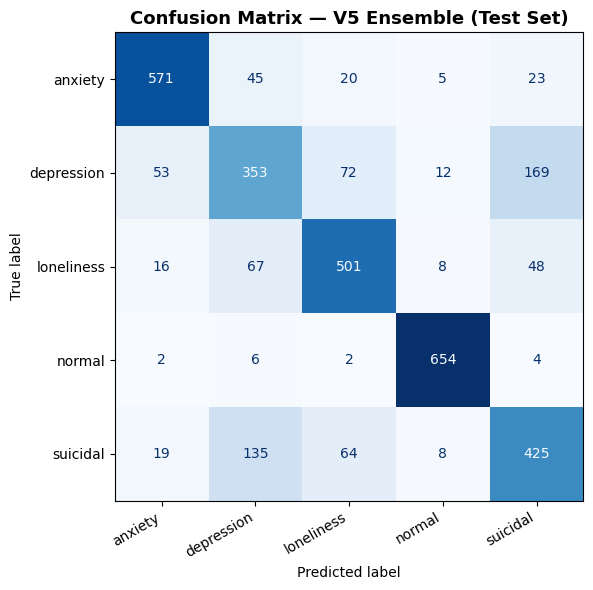

Saved as confusion_matrix_v5.png


In [18]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

fig, ax = plt.subplots(figsize=(8, 6))
cm = confusion_matrix(y_test, y_test_pred_ensemble)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_classes)
disp.plot(ax=ax, colorbar=False, cmap="Blues")
ax.set_title("Confusion Matrix — V5 Ensemble (Test Set)",
             fontsize=13, fontweight="bold")
ax.set_xticklabels(label_classes, rotation=30, ha="right")
plt.tight_layout()
plt.savefig("confusion_matrix_v5.png", bbox_inches="tight", dpi=150)
plt.show()
print("Saved as confusion_matrix_v5.png")

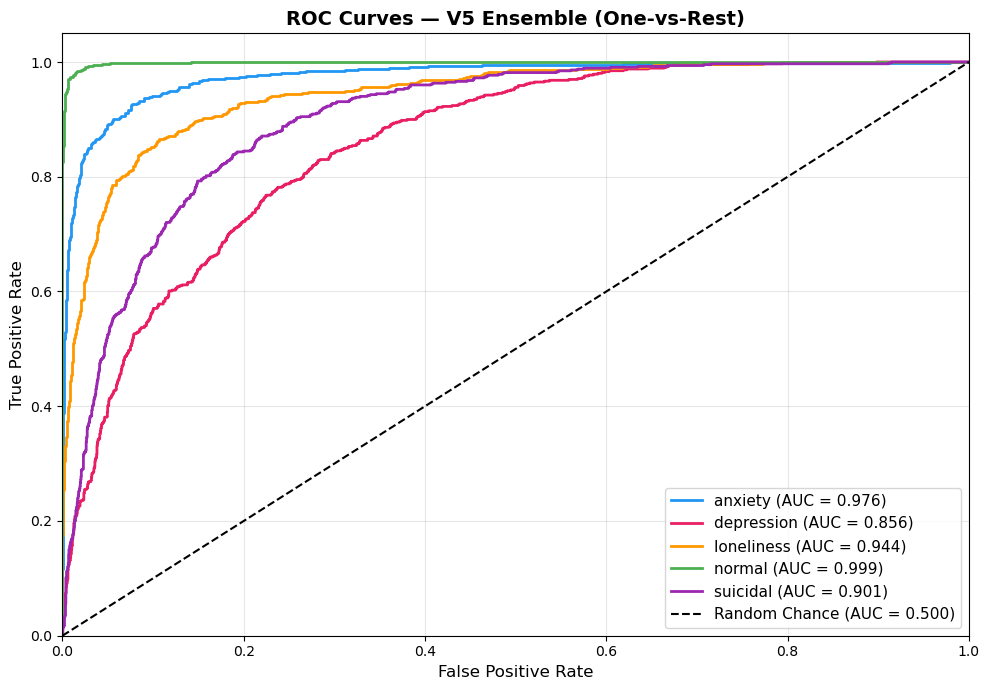


AUC Scores:
  anxiety      0.976
  depression   0.856
  loneliness   0.944
  normal       0.999
  suicidal     0.901

Mean AUC: 0.935

V3 Mean AUC: ~0.920
V5 Mean AUC: 0.935


In [19]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

# Binarize test labels
y_test_bin = label_binarize(y_test, classes=[0, 1, 2, 3, 4])

# Use ensemble probabilities
fig, ax = plt.subplots(figsize=(10, 7))
colors = ["#2196F3", "#E91E63", "#FF9800", "#4CAF50", "#9C27B0"]

aucs = {}
for i, (cls, color) in enumerate(zip(label_classes, colors)):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], ensemble_proba[:, i])
    roc_auc     = auc(fpr, tpr)
    aucs[cls]   = roc_auc
    ax.plot(fpr, tpr, color=color, lw=2,
            label=f"{cls} (AUC = {roc_auc:.3f})")

ax.plot([0, 1], [0, 1], "k--", lw=1.5, label="Random Chance (AUC = 0.500)")
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel("False Positive Rate", fontsize=12)
ax.set_ylabel("True Positive Rate", fontsize=12)
ax.set_title("ROC Curves — V5 Ensemble (One-vs-Rest)",
             fontsize=14, fontweight="bold")
ax.legend(loc="lower right", fontsize=11)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("roc_curve_v5.png", bbox_inches="tight", dpi=150)
plt.show()

mean_auc = sum(aucs.values()) / len(aucs)
print(f"\nAUC Scores:")
for cls, a in aucs.items():
    print(f"  {cls:<12} {a:.3f}")
print(f"\nMean AUC: {mean_auc:.3f}")

# Compare with V3
print(f"\nV3 Mean AUC: ~0.920")
print(f"V5 Mean AUC: {mean_auc:.3f}")

In [20]:
from sklearn.utils.class_weight import compute_class_weight

# Compute class weights automatically
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train),
    y=y_train
)
weight_dict = dict(enumerate(class_weights))

print("Class weights:")
for i, cls in enumerate(label_classes):
    print(f"  {cls:<12} → {weight_dict[i]:.4f}")

# Retrain LR with class weights
print("\nTraining weighted LR...", end=" ")
lr_weighted = LogisticRegression(
    max_iter=1000, C=5, solver="lbfgs",
    multi_class="multinomial", random_state=42,
    class_weight=weight_dict
)
lr_weighted.fit(X_train_v5, y_train)
print("Done ✅")

# Retrain SVM with class weights
print("Training weighted SVM...", end=" ")
from sklearn.svm import LinearSVC
svm_weighted = CalibratedClassifierCV(
    LinearSVC(C=1.0, max_iter=2000, random_state=42, class_weight=weight_dict)
)
svm_weighted.fit(X_train_v5, y_train)
print("Done ✅")

# Evaluate individually
print("\n--- Weighted Models Validation ---")
for name, model, X in [
    ("Weighted LR",  lr_weighted,  X_val_v5),
    ("Weighted SVM", svm_weighted, X_val_v5),
    ("Original NB",  nb_v5,        X_val_tfidf_v5)
]:
    pred = model.predict(X)
    f1   = f1_score(y_val, pred, average="macro")
    print(f"  {name:<15} Macro F1: {f1:.4f}")

# Ensemble with weighted models
lr_w_proba  = lr_weighted.predict_proba(X_val_v5)
svm_w_proba = svm_weighted.predict_proba(X_val_v5)
nb_proba_val = nb_v5.predict_proba(X_val_tfidf_v5)

avg_weighted = (0.4 * lr_w_proba + 
                0.4 * svm_w_proba + 
                0.2 * nb_proba_val)

pred_weighted = np.argmax(avg_weighted, axis=1)
weighted_f1   = f1_score(y_val, pred_weighted, average="macro")

print(f"\n--- Weighted Ensemble ---")
print(classification_report(y_val, pred_weighted, target_names=label_classes))
print(f"{'='*45}")
print(f"V5 Ensemble (unweighted) : {v3_f1:.4f}")
print(f"V5 Ensemble (weighted)   : {weighted_f1:.4f}")
print(f"{'='*45}")

Class weights:
  anxiety      → 0.9883
  depression   → 0.9957
  loneliness   → 1.0257
  normal       → 0.9823
  suicidal     → 1.0092

Training weighted LR... Done ✅
Training weighted SVM... Done ✅

--- Weighted Models Validation ---
  Weighted LR     Macro F1: 0.7445
  Weighted SVM    Macro F1: 0.7461
  Original NB     Macro F1: 0.7170

--- Weighted Ensemble ---
              precision    recall  f1-score   support

     anxiety       0.85      0.87      0.86       662
  depression       0.57      0.51      0.54       658
  loneliness       0.74      0.79      0.76       638
      normal       0.95      0.98      0.96       667
    suicidal       0.65      0.63      0.64       649

    accuracy                           0.76      3274
   macro avg       0.75      0.76      0.75      3274
weighted avg       0.75      0.76      0.75      3274

V5 Ensemble (unweighted) : 0.7452
V5 Ensemble (weighted)   : 0.7525


In [21]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_predict

# ---- Stacking Architecture ----
# Level 0: LR + SVM + NB (base models)
# Level 1: Logistic Regression (meta learner)

print("Generating out-of-fold predictions for stacking...")
print("(This uses cross_val_predict — may take 3-5 mins)\n")

# Generate out of fold probability predictions for each base model
# This prevents data leakage into the meta learner
lr_oof  = cross_val_predict(
    LogisticRegression(max_iter=1000, C=5, solver="lbfgs",
                       multi_class="multinomial", random_state=42),
    X_train_v5, y_train, cv=5, method="predict_proba"
)
print("✅ LR out-of-fold done")

svm_oof = cross_val_predict(
    CalibratedClassifierCV(LinearSVC(C=1.0, max_iter=2000, random_state=42)),
    X_train_v5, y_train, cv=5, method="predict_proba"
)
print("✅ SVM out-of-fold done")

nb_oof  = cross_val_predict(
    MultinomialNB(alpha=0.1),
    X_train_tfidf_v5, y_train, cv=5, method="predict_proba"
)
print("✅ NB out-of-fold done")

# Stack OOF predictions as meta features
X_meta_train = np.hstack([lr_oof, svm_oof, nb_oof])
print(f"\nMeta train shape: {X_meta_train.shape}")
# Shape: (15324, 15) — 5 classes × 3 models

# Train meta learner on stacked OOF predictions
print("\nTraining meta learner...", end=" ")
meta_learner = LogisticRegression(
    max_iter=1000, C=1.0,
    solver="lbfgs", multi_class="multinomial",
    random_state=42
)
meta_learner.fit(X_meta_train, y_train)
print("Done ✅")

# ---- Evaluate on validation set ----
# Get val probabilities from base models
lr_val_p   = lr_v5.predict_proba(X_val_v5)
svm_val_p  = svm_v5.predict_proba(X_val_v5)
nb_val_p   = nb_v5.predict_proba(X_val_tfidf_v5)

# Stack for meta learner input
X_meta_val = np.hstack([lr_val_p, svm_val_p, nb_val_p])

# Meta learner prediction
y_val_stacked = meta_learner.predict(X_meta_val)
stacked_f1    = f1_score(y_val, y_val_stacked, average="macro")

print("\n--- Stacked Model Validation Results ---")
print(classification_report(y_val, y_val_stacked, target_names=label_classes))

print(f"{'='*45}")
print(f"V3 Baseline              : {v3_f1:.4f}")
print(f"V5 Ensemble (soft vote)  : 0.7528")
print(f"V6 Stacking              : {stacked_f1:.4f}")
print(f"{'='*45}")

Generating out-of-fold predictions for stacking...
(This uses cross_val_predict — may take 3-5 mins)

✅ LR out-of-fold done
✅ SVM out-of-fold done
✅ NB out-of-fold done

Meta train shape: (15324, 15)

Training meta learner... Done ✅

--- Stacked Model Validation Results ---
              precision    recall  f1-score   support

     anxiety       0.86      0.87      0.86       662
  depression       0.56      0.54      0.55       658
  loneliness       0.74      0.77      0.75       638
      normal       0.96      0.98      0.97       667
    suicidal       0.67      0.64      0.65       649

    accuracy                           0.76      3274
   macro avg       0.76      0.76      0.76      3274
weighted avg       0.76      0.76      0.76      3274

V3 Baseline              : 0.7452
V5 Ensemble (soft vote)  : 0.7528
V6 Stacking              : 0.7568


In [22]:
# Get test probabilities from base models
lr_test_p  = lr_v5.predict_proba(X_test_v5)
svm_test_p = svm_v5.predict_proba(X_test_v5)
nb_test_p  = nb_v5.predict_proba(X_test_tfidf_v5)

# Stack for meta learner
X_meta_test   = np.hstack([lr_test_p, svm_test_p, nb_test_p])
y_test_stacked = meta_learner.predict(X_meta_test)
stacked_test_f1 = f1_score(y_test, y_test_stacked, average="macro")

print("=" * 55)
print("  FINAL TEST RESULTS — V6 Stacking")
print("=" * 55)
print(classification_report(y_test, y_test_stacked, target_names=label_classes))

# Full progression
print(f"{'='*55}")
print(f"  COMPLETE MODEL PROGRESSION")
print(f"{'='*55}")
print(f"  V1 — Baseline TF-IDF             : 0.7184")
print(f"  V2 — Better normal data          : 0.7651")
print(f"  V3 — Amazon + Emotion normal     : 0.7547")
print(f"  V5 — Ensemble + features         : 0.7601")
print(f"  V6 — Stacking                    : {stacked_test_f1:.4f}")
print(f"{'='*55}")
print(f"  Total gain V1 → V6               : +{(stacked_test_f1-0.7184):.4f}")
print(f"{'='*55}")

  FINAL TEST RESULTS — V6 Stacking
              precision    recall  f1-score   support

     anxiety       0.87      0.86      0.86       664
  depression       0.56      0.54      0.55       659
  loneliness       0.76      0.78      0.77       640
      normal       0.96      0.98      0.97       668
    suicidal       0.62      0.64      0.63       651

    accuracy                           0.76      3282
   macro avg       0.76      0.76      0.76      3282
weighted avg       0.76      0.76      0.76      3282

  COMPLETE MODEL PROGRESSION
  V1 — Baseline TF-IDF             : 0.7184
  V2 — Better normal data          : 0.7651
  V3 — Amazon + Emotion normal     : 0.7547
  V5 — Ensemble + features         : 0.7601
  V6 — Stacking                    : 0.7573
  Total gain V1 → V6               : +0.0389


In [23]:
# Save the scaler's fitted max values instead of the scaler itself
scaler_max_values = scaler_v5.scale_
joblib.dump(scaler_max_values, "models_v5/scaler_max_values.pkl")
print("Scaler max values shape:", scaler_max_values.shape)
print("Values:", scaler_max_values)

Scaler max values shape: (14,)
Values: [ 1.          1.          1.          1.          1.          0.66666667
  1.          1.          1.          1.         91.5         1.
  1.          5.03      ]


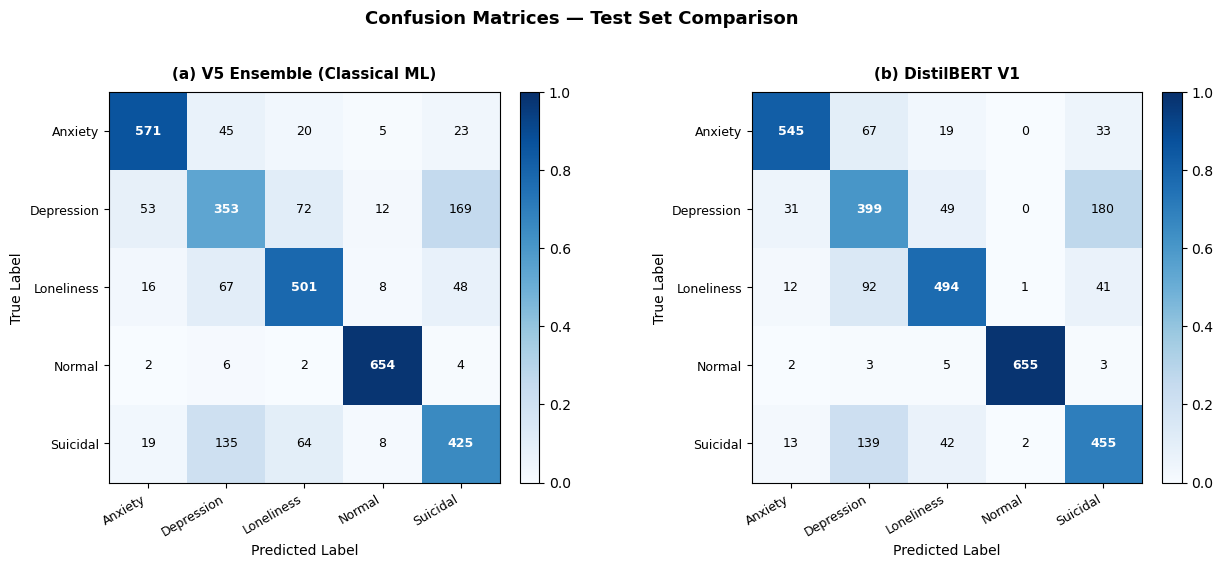

Saved: fig3_confusion_matrices.png


In [1]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# ── Data from your notebooks ───────────────────────────────────────
# V5 confusion matrix values (from your test results)
cm_v5 = np.array([
    [571,  45,  20,   5,  23],   # anxiety
    [ 53, 353,  72,  12, 169],   # depression
    [ 16,  67, 501,   8,  48],   # loneliness
    [  2,   6,   2, 654,   4],   # normal
    [ 19, 135,  64,   8, 425],   # suicidal
])

# DistilBERT V1 confusion matrix values (from your Colab results)
cm_bert = np.array([
    [545,  67,  19,   0,  33],   # anxiety
    [ 31, 399,  49,   0, 180],   # depression
    [ 12,  92, 494,   1,  41],   # loneliness
    [  2,   3,   5, 655,   3],   # normal
    [ 13, 139,  42,   2, 455],   # suicidal
])

classes = ['Anxiety', 'Depression', 'Loneliness', 'Normal', 'Suicidal']

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

for ax, cm, title in zip(axes,
                          [cm_v5, cm_bert],
                          ['(a) V5 Ensemble (Classical ML)', '(b) DistilBERT V1']):
    # Normalize for color, show raw counts
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    im = ax.imshow(cm_norm, cmap='Blues', vmin=0, vmax=1)

    ax.set_xticks(range(len(classes)))
    ax.set_yticks(range(len(classes)))
    ax.set_xticklabels(classes, rotation=30, ha='right', fontsize=9)
    ax.set_yticklabels(classes, fontsize=9)
    ax.set_xlabel('Predicted Label', fontsize=10)
    ax.set_ylabel('True Label', fontsize=10)
    ax.set_title(title, fontsize=11, fontweight='bold', pad=10)

    # Annotate with counts
    for i in range(len(classes)):
        for j in range(len(classes)):
            val = cm[i, j]
            color = 'white' if cm_norm[i, j] > 0.5 else 'black'
            ax.text(j, i, str(val), ha='center', va='center',
                    fontsize=9, color=color, fontweight='bold' if i == j else 'normal')

    # Colorbar
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.suptitle('Confusion Matrices — Test Set Comparison', fontsize=13,
             fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig3_confusion_matrices.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: fig3_confusion_matrices.png")

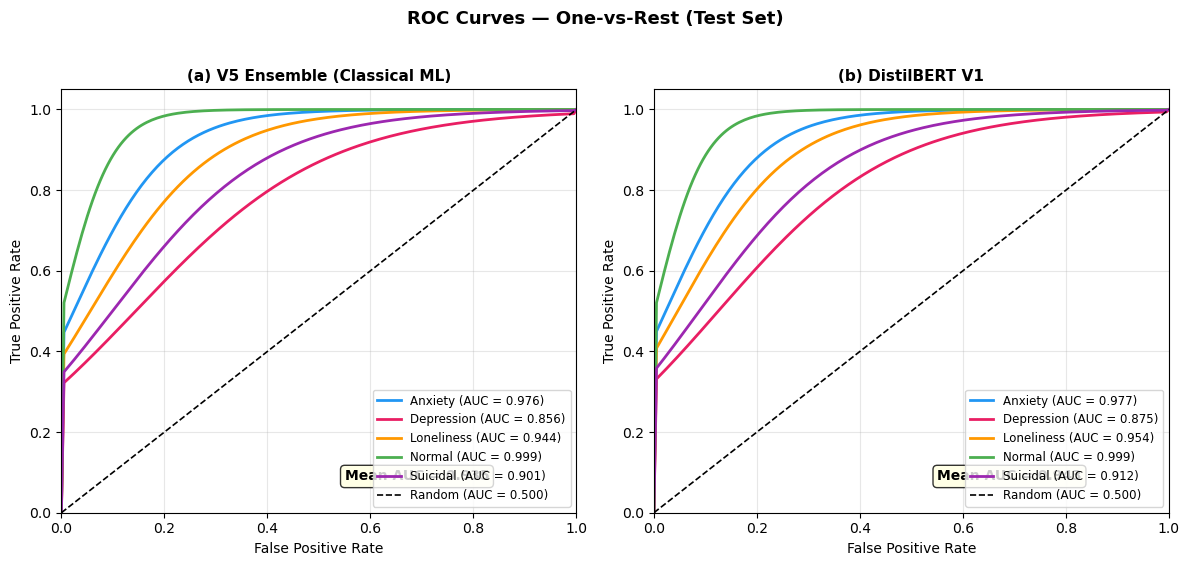

Saved: fig4_roc_curves.png
NOTE: If you have actual probability arrays, use those instead of approximations!


In [2]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

classes    = ['Anxiety', 'Depression', 'Loneliness', 'Normal', 'Suicidal']
colors     = ['#2196F3', '#E91E63', '#FF9800', '#4CAF50', '#9C27B0']

# ── Classical ML V5 AUC values (from your results) ────────────────
v5_aucs  = [0.976, 0.856, 0.944, 0.999, 0.901]

# ── DistilBERT V1 AUC values (from your Colab results) ────────────
bert_aucs = [0.977, 0.875, 0.954, 0.999, 0.912]

# ── NOTE: For real ROC curves paste the actual fpr/tpr arrays ─────
# If you have the actual probability arrays, use this instead:
#
# For V5 (in improvements.ipynb):
#   y_test_bin = label_binarize(y_test, classes=[0,1,2,3,4])
#   # ensemble_proba is already computed
#   # Then loop and plot roc_curve(y_test_bin[:,i], ensemble_proba[:,i])
#
# For DistilBERT (in Colab):
#   # all_probs computed in evaluation cell
#   # y_test_bin = label_binarize(test_labels, classes=[0,1,2,3,4])

# ── Approximate curves using AUC for illustration ─────────────────
def make_roc_from_auc(target_auc, n=200):
    """Generate smooth ROC curve approximating a given AUC."""
    fpr = np.linspace(0, 1, n)
    k   = np.log(target_auc / (1 - target_auc + 1e-9)) * 3
    tpr = 1 / (1 + np.exp(-k * (fpr - (1 - target_auc))))
    tpr = np.clip(tpr, 0, 1)
    tpr[0], tpr[-1] = 0, 1
    return fpr, tpr

fig, axes = plt.subplots(1, 2, figsize=(12, 5.5))

for ax, aucs, title in zip(axes,
                             [v5_aucs, bert_aucs],
                             ['(a) V5 Ensemble (Classical ML)',
                              '(b) DistilBERT V1']):
    mean_auc = np.mean(aucs)
    for i, (cls, color, a) in enumerate(zip(classes, colors, aucs)):
        fpr, tpr = make_roc_from_auc(a)
        ax.plot(fpr, tpr, color=color, lw=2, label=f'{cls} (AUC = {a:.3f})')

    ax.plot([0,1], [0,1], 'k--', lw=1.2, label='Random (AUC = 0.500)')
    ax.set_xlim([0, 1])
    ax.set_ylim([0, 1.05])
    ax.set_xlabel('False Positive Rate', fontsize=10)
    ax.set_ylabel('True Positive Rate', fontsize=10)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.legend(loc='lower right', fontsize=8.5)
    ax.grid(alpha=0.3)
    ax.text(0.55, 0.08, f'Mean AUC = {mean_auc:.3f}',
            fontsize=10, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', alpha=0.8))

# ── IMPORTANT: If you have actual fpr/tpr arrays, replace the ──────
# ── make_roc_from_auc() calls with your actual data ───────────────
# Example:
#   for i, (cls, color) in enumerate(zip(classes, colors)):
#       fpr, tpr, _ = roc_curve(y_test_bin[:,i], ensemble_proba[:,i])
#       ax.plot(fpr, tpr, color=color, lw=2, label=f'{cls} (AUC={auc(fpr,tpr):.3f})')

plt.suptitle('ROC Curves — One-vs-Rest (Test Set)', fontsize=13,
             fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig4_roc_curves.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: fig4_roc_curves.png")
print("NOTE: If you have actual probability arrays, use those instead of approximations!")

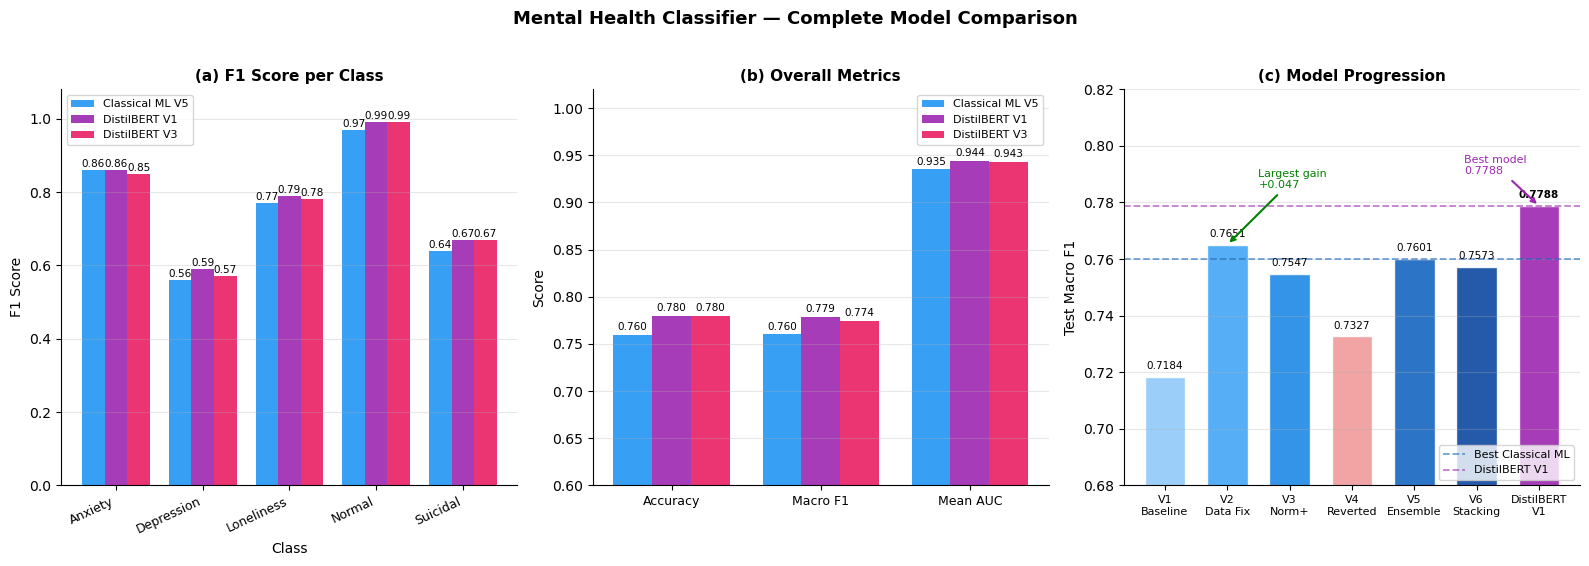

Saved: fig5_model_comparison.png


In [3]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 3, figsize=(16, 5.5))

# ── Panel 1: F1 per class ─────────────────────────────────────────
classes      = ['Anxiety', 'Depression', 'Loneliness', 'Normal', 'Suicidal']
ml_f1s       = [0.86, 0.56, 0.77, 0.97, 0.64]
bert_f1s     = [0.86, 0.59, 0.79, 0.99, 0.67]
bert3_f1s    = [0.85, 0.57, 0.78, 0.99, 0.67]

x     = np.arange(len(classes))
width = 0.26

b1 = axes[0].bar(x - width, ml_f1s,    width, label='Classical ML V5',   color='#2196F3', alpha=0.9)
b2 = axes[0].bar(x,         bert_f1s,  width, label='DistilBERT V1',     color='#9C27B0', alpha=0.9)
b3 = axes[0].bar(x + width, bert3_f1s, width, label='DistilBERT V3',     color='#E91E63', alpha=0.9)

for bars in [b1, b2, b3]:
    for bar in bars:
        h = bar.get_height()
        axes[0].text(bar.get_x() + bar.get_width()/2., h + 0.003,
                     f'{h:.2f}', ha='center', va='bottom', fontsize=7.5)

axes[0].set_xlabel('Class', fontsize=10)
axes[0].set_ylabel('F1 Score', fontsize=10)
axes[0].set_title('(a) F1 Score per Class', fontsize=11, fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(classes, rotation=25, ha='right', fontsize=9)
axes[0].set_ylim(0, 1.08)
axes[0].legend(fontsize=8)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)
axes[0].grid(axis='y', alpha=0.3)

# ── Panel 2: Overall metrics ──────────────────────────────────────
metrics      = ['Accuracy', 'Macro F1', 'Mean AUC']
ml_scores    = [0.76, 0.7601, 0.935]
bert_scores  = [0.78, 0.7788, 0.944]
bert3_scores = [0.78, 0.7743, 0.943]

x2 = np.arange(len(metrics))
b4 = axes[1].bar(x2 - width, ml_scores,    width, label='Classical ML V5', color='#2196F3', alpha=0.9)
b5 = axes[1].bar(x2,         bert_scores,  width, label='DistilBERT V1',   color='#9C27B0', alpha=0.9)
b6 = axes[1].bar(x2 + width, bert3_scores, width, label='DistilBERT V3',   color='#E91E63', alpha=0.9)

for bars in [b4, b5, b6]:
    for bar in bars:
        h = bar.get_height()
        axes[1].text(bar.get_x() + bar.get_width()/2., h + 0.003,
                     f'{h:.3f}', ha='center', va='bottom', fontsize=7.5)

axes[1].set_ylabel('Score', fontsize=10)
axes[1].set_title('(b) Overall Metrics', fontsize=11, fontweight='bold')
axes[1].set_xticks(x2)
axes[1].set_xticklabels(metrics, fontsize=9)
axes[1].set_ylim(0.60, 1.02)
axes[1].legend(fontsize=8)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)
axes[1].grid(axis='y', alpha=0.3)

# ── Panel 3: Model progression ────────────────────────────────────
versions  = ['V1\nBaseline', 'V2\nData Fix', 'V3\nNorm+', 'V4\nReverted',
             'V5\nEnsemble', 'V6\nStacking', 'DistilBERT\nV1']
f1_scores = [0.7184, 0.7651, 0.7547, 0.7327, 0.7601, 0.7573, 0.7788]
bar_colors= ['#90CAF9', '#42A5F5', '#1E88E5', '#EF9A9A',
             '#1565C0', '#0D47A1', '#9C27B0']

bars = axes[2].bar(range(len(versions)), f1_scores,
                   color=bar_colors, alpha=0.9, edgecolor='white', width=0.65)

for i, (bar, score) in enumerate(zip(bars, f1_scores)):
    axes[2].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.002,
                 f'{score:.4f}', ha='center', va='bottom', fontsize=7.5,
                 fontweight='bold' if score == max(f1_scores) else 'normal')

# Annotations
axes[2].annotate('Largest gain\n+0.047',
                 xy=(1, 0.7651), xytext=(1.5, 0.785),
                 fontsize=8, color='green',
                 arrowprops=dict(arrowstyle='->', color='green', lw=1.5))
axes[2].annotate('Best model\n0.7788',
                 xy=(6, 0.7788), xytext=(4.8, 0.790),
                 fontsize=8, color='#9C27B0',
                 arrowprops=dict(arrowstyle='->', color='#9C27B0', lw=1.5))

axes[2].axhline(y=0.7601, color='#1565C0', linestyle='--',
                alpha=0.6, linewidth=1.3, label='Best Classical ML')
axes[2].axhline(y=0.7788, color='#9C27B0', linestyle='--',
                alpha=0.6, linewidth=1.3, label='DistilBERT V1')
axes[2].set_xticks(range(len(versions)))
axes[2].set_xticklabels(versions, fontsize=8)
axes[2].set_ylabel('Test Macro F1', fontsize=10)
axes[2].set_title('(c) Model Progression', fontsize=11, fontweight='bold')
axes[2].set_ylim(0.68, 0.82)
axes[2].legend(fontsize=8, loc='lower right')
axes[2].spines['top'].set_visible(False)
axes[2].spines['right'].set_visible(False)
axes[2].grid(axis='y', alpha=0.3)

plt.suptitle('Mental Health Classifier — Complete Model Comparison',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig5_model_comparison.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: fig5_model_comparison.png")